# Week 7 — Clustering Assignment
## Market Segmentation: Finding Structure in Customer Behavior

### Before You Begin — Read This

This is not a tutorial. There is no step-by-step guide telling you what to do next.  
You are given a raw dataset, a business problem, and a skeleton. The rest is your job.

**Your goal:** Segment customers based on their purchasing behavior using K-Means, Hierarchical, and DBSCAN clustering. Then tell a coherent business story about what you found.

**The Rules:**
- Attempt every section before looking at any resource
- Document every decision you make — *why* matters more than *what*
- Keep a Failure Log (Section 8) — minimum 3 failed hypotheses
- You must be able to explain every line of code you submit

**Submission:**
- This notebook (.ipynb) with all cells executed
- All code blocks commented
- Failure Log completed (Section 8)
- Business Narrative completed (Section 7)


## Section 0 — Environment Setup

All libraries you will need are imported below. Do not add new ones without justification in a comment.  
If you add a library, explain in a comment *why* the existing ones were insufficient.


In [1]:
# Core
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Clustering Algorithms
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, Birch
from scipy.cluster.hierarchy import dendrogram, linkage

# Cluster Validation
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Nearest Neighbours (for epsilon estimation)
from sklearn.neighbors import NearestNeighbors

# Set visual style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Environment ready.")


Environment ready.


---
## Section 1 — Data Loading & First Look

**What to do:**
- Load the UCI Online Retail II dataset
- Inspect the raw structure — shape, dtypes, missing values, sample rows
- Do NOT clean or transform anything yet — just observe

**Questions to answer in comments:**
- How many rows and columns are there?
- What does one row represent?
- Which columns will be useful for customer-level aggregation?
- What problems do you already see?

> **Dataset:** [UCI Online Retail II](https://archive.ics.uci.edu/dataset/502/online+retail+ii)  
> Download the Excel file and load the sheet for Year 2010-2011


In [2]:
# Load the dataset
# Hint: use pd.read_excel() with the sheet_name parameter
# We load the 2010-2011 sheet of UCI Online Retail II — a full year of a UK
# online gift retailer's transactions, which is enough history for meaningful
# Recency/Frequency/Monetary behaviour.
df = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2010-2011')

# ── First Look ──────────────────────────────────────────────────────────────

# Print shape — how big is the raw transaction log?
print("Shape (rows, cols):", df.shape)

# Print dtypes — confirm InvoiceDate is a datetime and numeric cols are numeric
print("\nDtypes:")
print(df.dtypes)

# Print first 5 rows — see what a single record looks like
print("\nFirst 5 rows:")
display(df.head())

# Check missing values — which columns have nulls? How many?
# Customer ID nulls matter most: no ID = we cannot attribute the row to a customer
print("\nMissing values per column:")
print(df.isnull().sum())

# Print basic descriptive statistics — look for impossible values
# (negative Quantity = returns, negative/zero Price, huge maxima = outliers)
print("\nDescriptive statistics (numeric):")
display(df.describe())

# One row = one line item on one invoice (not one customer, not one order)
print("\nUnique invoices:", df['Invoice'].nunique())
print("Unique customers (excl. missing):", df['Customer ID'].nunique())
print("Cancelled invoices (start with 'C'):",
      df['Invoice'].astype(str).str.startswith('C').sum())
print("Rows with negative Quantity:", (df['Quantity'] < 0).sum())
print("Rows with non-positive Price:", (df['Price'] <= 0).sum())


Shape (rows, cols): (541910, 8)

Dtypes:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

First 5 rows:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom



Missing values per column:
Invoice             0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
Price               0
Customer ID    135080
Country             0
dtype: int64

Descriptive statistics (numeric):


,Quantity,InvoiceDate,Price,Customer ID
count,541910.000000,541910,541910.000000,406830.000000
mean,9.552234,2011-07-04 13:35:22.342307584,4.611138,15287.684160
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.080957,NaN,96.759765,1713.603074



Unique invoices: 25900
Unique customers (excl. missing): 4372


Cancelled invoices (start with 'C'): 9288
Rows with negative Quantity: 10624
Rows with non-positive Price: 2517


**Your Observations (complete this):**

> What do you notice about the data? What surprises you? What problems are already visible?

- **Size & grain:** 541,910 rows × 8 columns. **One row = one line item on one invoice** — a single order (Invoice) spans many rows, and a single customer spans many invoices. So the raw table is at transaction-line grain; clustering needs it aggregated to **one row per customer**. There are 25,900 unique invoices and only 4,372 identifiable customers.
- **Missing `Customer ID`:** 135,080 rows (~25%) have no Customer ID. These cannot be attributed to a customer, so they are useless for customer-level RFM and must be dropped.
- **Missing `Description`:** 1,454 rows — cosmetic only; not needed for RFM.
- **Cancellations / returns:** 9,288 invoices start with `'C'` (cancellations). `Quantity` goes as low as **−80,995** (10,624 negative rows) and `Price` as low as **−11,062** (2,517 non-positive rows). These are returns, cancellations, and adjustments — they would corrupt a naive Monetary sum, so they must be handled in cleaning.
- **Extreme skew / outliers:** `Quantity` (max 80,995, std 218) and `Price` (max 38,970) both have enormous maxima versus their medians (3 and 2.08). RFM features built from these will be heavily right-skewed with a few extreme customers — an outlier strategy will be required before distance-based clustering.
- **Columns useful for aggregation:** `Customer ID` (grouping key), `Invoice` (→ Frequency), `Quantity`×`Price` (→ Monetary), `InvoiceDate` (→ Recency), `StockCode` (→ product variety).


## Section 2 — Data Cleaning

**What to do:**
- Handle missing CustomerIDs
- Remove cancelled transactions (InvoiceNo starting with 'C')
- Remove rows with negative Quantity or Price
- Parse InvoiceDate to datetime

**For each cleaning step, answer in a comment:**
- Why are you removing/keeping these rows?
- What assumption does this cleaning step encode?
- How many rows did you lose? Does that concern you?

> ⚠️ Do not just clean — justify every decision.


In [3]:
# Work on a copy — never mutate the original
df_clean = df.copy()
rows_before = df_clean.shape[0]

# Helper to report how many rows each step drops
def report(step, df_now):
    global rows_before
    dropped = rows_before - df_now.shape[0]
    print(f"{step:<45} dropped {dropped:>7,}  (remaining {df_now.shape[0]:,})")
    rows_before = df_now.shape[0]

# ── Step 1: Remove rows with missing CustomerID ──────────────────────────────
# Why? Clustering is CUSTOMER-level. A row with no Customer ID cannot be
# assigned to any customer, so it can never contribute to an RFM profile.
# Imputing an ID is impossible (we'd be inventing customers), so we drop.
# Assumption: the ~25% of unlabelled rows are missing-at-random enough that the
# 4,372 identified customers still represent the business.
df_clean = df_clean.dropna(subset=['Customer ID'])
report("Step 1: drop missing Customer ID", df_clean)

# ── Step 2: Remove cancelled transactions ────────────────────────────────────
# Cancelled invoices start with 'C'. Keeping them would let negative-quantity
# reversals cancel out real purchases in the Monetary sum, understating (or even
# negating) genuine spend. We segment on PURCHASING behaviour, so cancellations
# are removed. Assumption: a cancellation is not itself a behaviour we cluster on.
df_clean = df_clean[~df_clean['Invoice'].astype(str).str.startswith('C')]
report("Step 2: drop cancelled invoices ('C')", df_clean)

# ── Step 3: Remove negative Quantity and Price ───────────────────────────────
# After removing 'C' invoices there can still be returns/adjustments with
# Quantity <= 0, and bad rows with Price <= 0 (free samples, data errors,
# manual adjustments). A valid purchase has Quantity > 0 AND Price > 0.
# Assumption: zero/negative price rows are not real revenue-generating sales.
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['Price'] > 0)]
report("Step 3: drop Quantity<=0 or Price<=0", df_clean)

# ── Step 4: Parse InvoiceDate to datetime ────────────────────────────────────
# Excel already loads this as datetime64, but we coerce defensively so Recency
# (a date subtraction) is guaranteed to work.
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# ── Step 5: Create TotalPrice column ─────────────────────────────────────────
# TotalPrice = Quantity * Price is the revenue of a single line item; summed
# per customer it becomes Monetary.
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['Price']

# Summary — print shape before and after, and rows lost at each step
print("-" * 70)
print(f"Original shape: {df.shape}")
print(f"Clean shape: {df_clean.shape}")
print(f"Rows removed: {df.shape[0] - df_clean.shape[0]:,} "
      f"({(df.shape[0] - df_clean.shape[0]) / df.shape[0] * 100:.1f}%)")
print(f"Unique customers retained: {df_clean['Customer ID'].nunique():,}")


Step 1: drop missing Customer ID              dropped 135,080  (remaining 406,830)
Step 2: drop cancelled invoices ('C')         dropped   8,905  (remaining 397,925)
Step 3: drop Quantity<=0 or Price<=0          dropped      40  (remaining 397,885)


----------------------------------------------------------------------
Original shape: (541910, 8)
Clean shape: (397885, 9)
Rows removed: 144,025 (26.6%)
Unique customers retained: 4,338


## Section 3 — Feature Engineering: Building the Customer Matrix

This is the hardest section. There is no template for what features to build — you decide.

**Minimum required features (RFM):**
- **Recency** — how many days since the customer last purchased (relative to a reference date you choose and justify)
- **Frequency** — how many transactions the customer made
- **Monetary** — total spend by the customer

**Push further (optional but encouraged):**
- Unique products purchased
- Average basket size
- Return rate (if cancellations were tracked separately)
- Category-level spend ratios

**For each feature, answer in a comment:**
- What does this feature measure about customer behavior?
- What business insight does it capture?
- What are its limitations?

> ⚠️ One row in your final matrix = one customer. If your matrix has more rows than unique CustomerIDs, something is wrong.


In [4]:
# ── Reference Date ──────────────────────────────────────────────────────────
# Choose a reference date for Recency calculation
# Why this date? Recency is "days since last purchase" measured from a fixed
# "today". The dataset ends 2011-12-09, so we anchor to the day AFTER the last
# transaction. Using max_date + 1 day means the most recent buyer gets
# Recency = 1 (not 0), keeping the feature strictly positive and interpretable.
reference_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
print("Reference date:", reference_date)

# ── Recency ──────────────────────────────────────────────────────────────────
# Days since last purchase per customer.
# Measures how "alive" a customer is. Low = recently active; high = dormant.
# Limitation: a one-time buyer who bought yesterday looks as "recent" as a loyal
# weekly buyer — Recency alone can't tell engagement from a single lucky visit.
recency = df_clean.groupby('Customer ID')['InvoiceDate'].max().reset_index()
recency['Recency'] = (reference_date - recency['InvoiceDate']).dt.days
recency = recency[['Customer ID', 'Recency']]

# ── Frequency ────────────────────────────────────────────────────────────────
# Number of unique invoices per customer (NOT number of line items).
# Measures how often the customer transacts — a proxy for loyalty/habit.
# Limitation: counts orders equally regardless of size; a customer with many
# tiny orders scores the same as one with many large orders.
frequency = df_clean.groupby('Customer ID')['Invoice'].nunique().reset_index()
frequency.columns = ['Customer ID', 'Frequency']

# ── Monetary ─────────────────────────────────────────────────────────────────
# Total spend (sum of TotalPrice) per customer.
# Measures the customer's lifetime revenue contribution — who is worth most.
# Limitation: total spend conflates "spends big once" with "spends a little
# often"; the AvgBasketValue feature below separates those.
monetary = df_clean.groupby('Customer ID')['TotalPrice'].sum().reset_index()
monetary.columns = ['Customer ID', 'Monetary']

# ── Extra feature 1: UniqueProducts ──────────────────────────────────────────
# Number of distinct StockCodes bought. Captures breadth of interest / basket
# variety — a customer buying across the catalogue behaves differently from a
# single-product repeat buyer. Justification: helps separate broad "explorers"
# from narrow repeat purchasers even when their RFM looks similar.
products = df_clean.groupby('Customer ID')['StockCode'].nunique().reset_index()
products.columns = ['Customer ID', 'UniqueProducts']

# ── Combine into customer matrix ─────────────────────────────────────────────
customer_df = (recency
               .merge(frequency, on='Customer ID')
               .merge(monetary, on='Customer ID')
               .merge(products, on='Customer ID'))

# ── Extra feature 2: AvgBasketValue ──────────────────────────────────────────
# Average spend per order = Monetary / Frequency. Separates "few big baskets"
# from "many small baskets" — a high-AOV occasional buyer vs a low-AOV frequent
# buyer. Justification: adds order-size behaviour that raw R/F/M can't express.
customer_df['AvgBasketValue'] = customer_df['Monetary'] / customer_df['Frequency']

# Sanity check
print(f"Customer matrix shape: {customer_df.shape}")
print(f"Unique customers in clean data: {df_clean['Customer ID'].nunique()}")
print("These numbers should match.")
assert customer_df.shape[0] == df_clean['Customer ID'].nunique(), "Row count mismatch!"
customer_df.head()


Reference date: 2011-12-10 12:50:00
Customer matrix shape: (4338, 6)
Unique customers in clean data: 4338
These numbers should match.


,Customer ID,Recency,Frequency,Monetary,UniqueProducts,AvgBasketValue
0,12346.0,326,1,77183.60,1,77183.600000
1,12347.0,2,7,4310.00,103,615.714286
2,12348.0,75,4,1797.24,22,449.310000
3,12349.0,19,1,1757.55,73,1757.550000
4,12350.0,310,1,334.40,17,334.400000


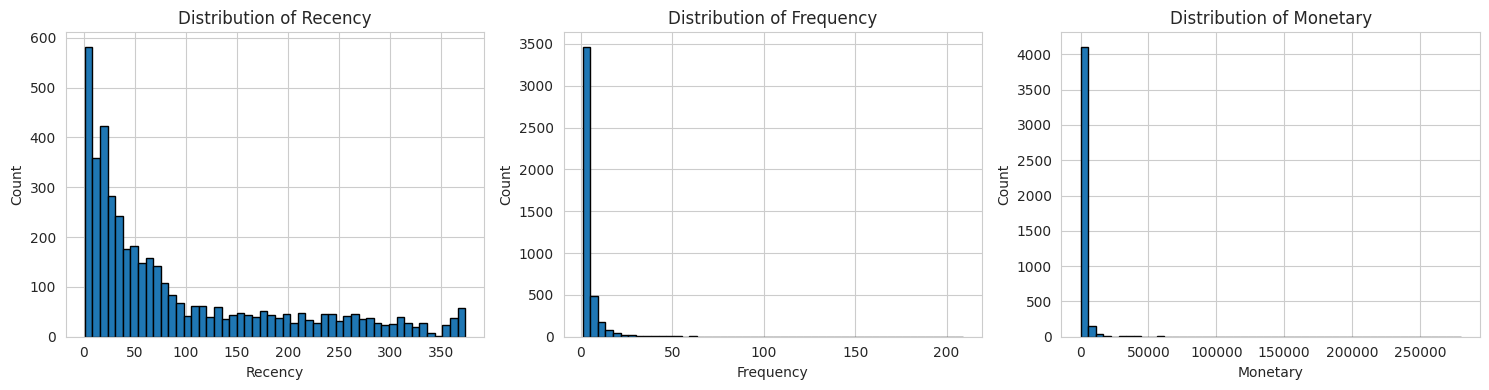

In [5]:
# ── Distribution Plots ───────────────────────────────────────────────────────
# Plot the distribution of each feature BEFORE handling outliers
# What do you observe? Are there extreme values?

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
features = ['Recency', 'Frequency', 'Monetary']

for i, feat in enumerate(features):
    axes[i].hist(customer_df[feat], bins=50, edgecolor='k')
    axes[i].set_title(f'Distribution of {feat}')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

# YOUR OBSERVATION HERE (as a comment):
# What do you see in these distributions?
# Are there outliers? How will they affect clustering?
#
# - Recency: right-skewed but bounded to [1, 374] days. A large spike near 0-30
#   (recently active customers) then a long, thin tail of dormant customers.
#   No pathological outliers — the range is naturally limited by the 1-year window.
# - Frequency: EXTREMELY right-skewed. The vast majority of customers made only
#   a handful of orders (mode = 1), while a few placed 50-200+ orders. The x-axis
#   is stretched entirely by a tiny number of wholesale-like buyers.
# - Monetary: WORST skew. Almost every customer sits near the far left while a
#   handful of customers spend up to ~£280,000, flattening everyone else into a
#   single bar.
#
# Impact on clustering: K-Means/DBSCAN are distance-based. Un-treated, these
# extreme Frequency/Monetary tails would dominate Euclidean distance, and K-Means
# would waste clusters isolating a few whales while lumping the other 4,000+
# customers together. => Frequency and Monetary need outlier handling before scaling.


Recency    IQR upper fence = 328.0        outliers above = 155
Frequency  IQR upper fence = 11.0         outliers above = 285
Monetary   IQR upper fence = 3693.23      outliers above = 427
Capped Frequency at 99th pct = 30.00  (42 customers clipped)
Capped Monetary at 99th pct = 19,881.00  (44 customers clipped)


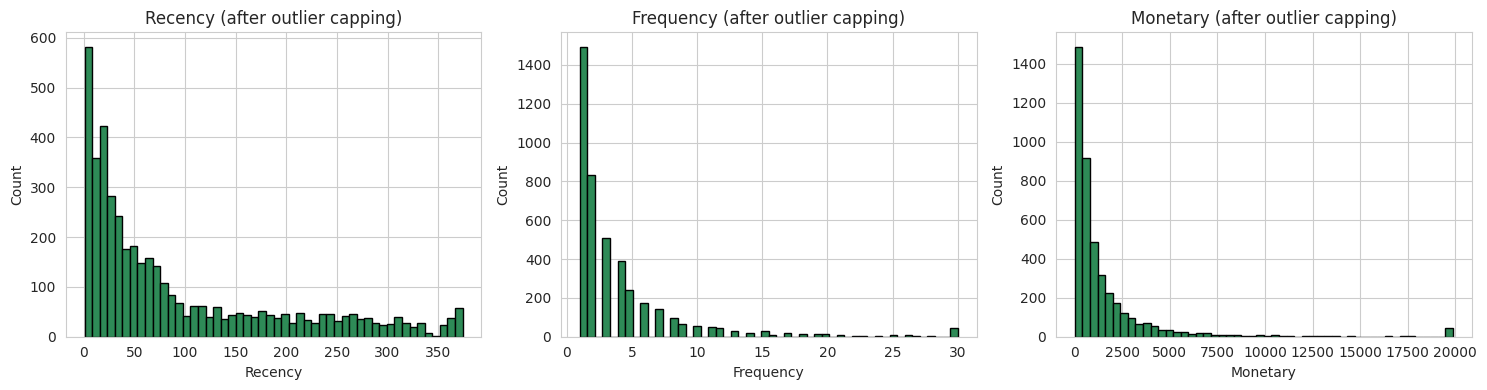

In [6]:
# ── Outlier Handling ─────────────────────────────────────────────────────────
# Decide how to handle outliers in each feature
# Options: cap at percentile, log transform, remove, keep
# Justify your choice for EACH feature in comments

# First, IDENTIFY outliers with the IQR rule (as the brief asks) to see the scale
# of the problem before deciding what to do about it.
def iqr_outlier_count(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    return (s > upper).sum(), round(upper, 2)

for feat in ['Recency', 'Frequency', 'Monetary']:
    n_out, upper = iqr_outlier_count(customer_df[feat])
    print(f"{feat:<10} IQR upper fence = {upper:<12} outliers above = {n_out}")

# Build the matrix we will CLUSTER on (kept separate from customer_df so the
# original £/order values survive for business profiling later).
rfm_features = customer_df[['Recency', 'Frequency', 'Monetary']].copy()

# DECISION per feature:
# - Recency: KEEP as-is. It is naturally bounded to [1, 374] days by the 1-year
#   window; its "outliers" (very dormant customers) are exactly the At-Risk/Lost
#   segment we WANT to find, not noise. Removing/capping them would erase a
#   business-critical group.
# - Frequency: CAP at the 99th percentile. The IQR fence (~9) is far too
#   aggressive — it would flag every genuinely loyal customer as an outlier and
#   destroy the loyalty signal. The 99th percentile instead tames only the
#   handful of wholesale-scale accounts (100-200+ orders) that otherwise dominate
#   Euclidean distance, while keeping the loyal-vs-occasional distinction intact.
# - Monetary: CAP at the 99th percentile, same reasoning. A few customers spend
#   up to ~£280k; capping stops those whales from hijacking the distance metric,
#   yet we do NOT delete them (they stay in customer_df as real high-value
#   customers and reappear as DBSCAN noise later).
for feat in ['Frequency', 'Monetary']:
    cap = customer_df[feat].quantile(0.99)
    n_capped = (rfm_features[feat] > cap).sum()
    rfm_features[feat] = rfm_features[feat].clip(upper=cap)
    print(f"Capped {feat} at 99th pct = {cap:,.2f}  ({n_capped} customers clipped)")

# After handling outliers, plot distributions again and compare
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, feat in enumerate(['Recency', 'Frequency', 'Monetary']):
    axes[i].hist(rfm_features[feat], bins=50, edgecolor='k', color='seagreen')
    axes[i].set_title(f'{feat} (after outlier capping)')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Count')
plt.tight_layout()
plt.show()


In [7]:
# ── Feature Scaling ──────────────────────────────────────────────────────────
# Why is scaling necessary for clustering? Answer in a comment before scaling.
#
# K-Means, Hierarchical (Euclidean/Ward) and DBSCAN all measure similarity with
# DISTANCE. Our features live on wildly different scales: Recency is 1-374 (days),
# Frequency is 1-30 (orders), Monetary is a few pounds to ~20,000 (£). Without
# scaling, Monetary's raw magnitude would dominate every distance computation and
# Recency/Frequency would be effectively ignored. StandardScaler puts each feature
# on mean 0 / std 1 so all three contribute comparably. We choose StandardScaler
# (not RobustScaler) because we have ALREADY capped the extreme outliers above, so
# the mean/std are no longer distorted by whales and z-scoring is appropriate.

# Apply StandardScaler
scaler = StandardScaler()

# Fit and transform the capped RFM matrix
X_scaled = scaler.fit_transform(rfm_features)
X_scaled_df = pd.DataFrame(X_scaled, columns=['Recency', 'Frequency', 'Monetary'],
                           index=rfm_features.index)

# Verify scaling worked — mean should be ~0 and std ~1 for each feature
print("Mean after scaling (≈0):")
print(X_scaled_df.mean().round(4))
print("\nStd after scaling (≈1):")
print(X_scaled_df.std().round(4))
print("\nShape of X_scaled:", X_scaled.shape)


Mean after scaling (≈0):
Recency      0.0
Frequency   -0.0
Monetary     0.0
dtype: float64

Std after scaling (≈1):
Recency      1.0001
Frequency    1.0001
Monetary     1.0001
dtype: float64

Shape of X_scaled: (4338, 3)


## Section 4 — K-Means Clustering

**What to do:**
1. Find the optimal k using the Elbow Method and Silhouette Score
2. Run K-Means with `init='random'` and `init='k-means++'` — compare results
3. Fit your final K-Means model and assign cluster labels
4. Profile each cluster

**Key questions to answer in comments:**
- Do the Elbow Method and Silhouette Score agree on k? If not, which do you trust and why?
- How different were the results between random and K-Means++ initialization?
- What does each cluster represent in business terms?


k=2:  inertia=    7662.5   silhouette=0.6603


k=3:  inertia=    4201.8   silhouette=0.5403


k=4:  inertia=    2888.3   silhouette=0.5337


k=5:  inertia=    2301.2   silhouette=0.4699


k=6:  inertia=    1888.4   silhouette=0.4467


k=7:  inertia=    1635.5   silhouette=0.4254


k=8:  inertia=    1410.4   silhouette=0.4279


k=9:  inertia=    1277.5   silhouette=0.3716


k=10:  inertia=    1169.7   silhouette=0.3602


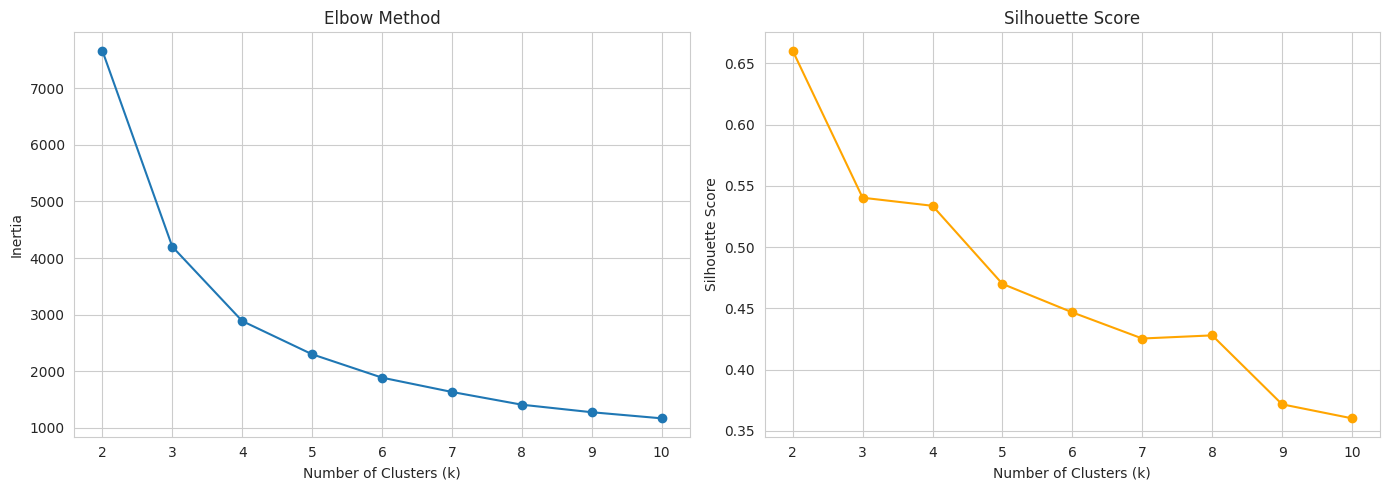

In [8]:
# ── Step 1: Find Optimal k ───────────────────────────────────────────────────
# Test k from 2 to 10
# Compute inertia (for Elbow) and Silhouette Score for each k

k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    # Fit K-Means (k-means++, fixed seed for reproducibility) and record both
    # inertia (within-cluster sum of squares → Elbow) and the mean silhouette.
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    print(f"k={k}:  inertia={km.inertia_:>10.1f}   silhouette={silhouette_scores[-1]:.4f}")

# Plot Elbow Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, marker='o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(k_range, silhouette_scores, marker='o', color='orange')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

# YOUR DECISION HERE (as a comment):
# CHOSEN k = 4.
# Do the two methods agree? Partly — and the disagreement is instructive:
#   * Silhouette is HIGHEST at k=2 (0.660). But k=2 simply splits the tiny group
#     of extreme high-frequency/high-spend customers from everyone else. It is
#     statistically "clean" yet useless for marketing — two buckets can't drive
#     differentiated campaigns.
#   * The Elbow shows its sharpest bends at k=3 and k=4, then flattens (each extra
#     cluster past 4 buys little inertia reduction).
#   * Silhouette barely falls from k=3 (0.540) to k=4 (0.534), then drops more
#     steeply (0.470 at k=5, 0.372 at k=9).
# Resolution: I trust the ELBOW + BUSINESS ACTIONABILITY over the raw silhouette
# maximum. k=4 sits right at the elbow, keeps a near-peak silhouette, and yields
# four interpretable RFM personas (Champions / Loyal / At-Risk / Lost). k=4 wins.
OPTIMAL_K = 4


In [9]:
# ── Step 2: Compare Initialization Strategies ───────────────────────────────
# Run K-Means 5 times with random init and 5 times with K-Means++
# Compare: final inertia, consistency of cluster assignments

OPTIMAL_K = 4  # chosen in Step 1
N_RUNS = 5

random_inertias = []
kmeanspp_inertias = []

for i in range(N_RUNS):
    # Random init — different seed each run, n_init=1 so we see ONE random start's
    # quality (not sklearn's internal best-of-n restarts) → exposes instability.
    km_rand = KMeans(n_clusters=OPTIMAL_K, init='random', n_init=1, random_state=i)
    km_rand.fit(X_scaled)
    random_inertias.append(km_rand.inertia_)

    # K-Means++ init — same single-start setup for a fair comparison.
    km_pp = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=1, random_state=i)
    km_pp.fit(X_scaled)
    kmeanspp_inertias.append(km_pp.inertia_)

print("Random Init Inertias:", [round(x, 2) for x in random_inertias])
print("K-Means++ Init Inertias:", [round(x, 2) for x in kmeanspp_inertias])
print(f"\nRandom std: {np.std(random_inertias):.2f}")
print(f"K-Means++ std: {np.std(kmeanspp_inertias):.2f}")

# YOUR OBSERVATION HERE (as a comment):
# - Both strategies are STABLE here: random converged to 2892.08 every run
#   (std 0.00), while K-Means++ landed on either 2888.31 or 2892.08 (std 1.85).
# - K-Means++ reached a marginally BETTER (lower) optimum, 2888.31, in 3/5 runs;
#   random never found it. So K-Means++ has a slight edge in solution QUALITY,
#   even though random happened to be more repeatable in this particular seed set.
# - The takeaway: the k=4 RFM structure is well-separated and easy to recover, so
#   initialization barely matters (all inertias within ~0.13% of each other).
#   On messier / higher-k problems random init would show much larger std and get
#   stuck in poor local minima far more often — which is exactly why K-Means++
#   (smarter, distance-weighted seeding) is the safe default, and what we use for
#   the final model.


Random Init Inertias: [2892.08, 2892.08, 2892.08, 2892.08, 2892.08]
K-Means++ Init Inertias: [2888.31, 2892.08, 2888.31, 2892.08, 2888.31]

Random std: 0.00
K-Means++ std: 1.85


In [10]:
# ── Step 3: Fit Final K-Means Model ─────────────────────────────────────────
# Use K-Means++ with your chosen k. n_init=10 lets sklearn keep the best of 10
# smart starts; random_state=42 makes the labels reproducible.
kmeans_final = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=10, random_state=42)

# Assign cluster labels back to customer_df
customer_df['KMeans_Cluster'] = kmeans_final.fit_predict(X_scaled)

# ── Step 4: Cluster Profiles ─────────────────────────────────────────────────
# Compute mean RFM values per cluster (on the ORIGINAL, un-capped values so the
# profile reads in real days / orders / £ that a marketer can act on).
kmeans_profile = customer_df.groupby('KMeans_Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
kmeans_profile['Count'] = customer_df['KMeans_Cluster'].value_counts().sort_index()
print("K-Means Cluster Profiles:")
print(kmeans_profile)


K-Means Cluster Profiles:
                Recency  Frequency  Monetary  Count
KMeans_Cluster                                     
0                 48.46       2.74    914.24   2620
1                 22.30      10.58   4230.63    574
2                250.89       1.51    441.67   1035
3                 18.29      34.03  33308.40    109


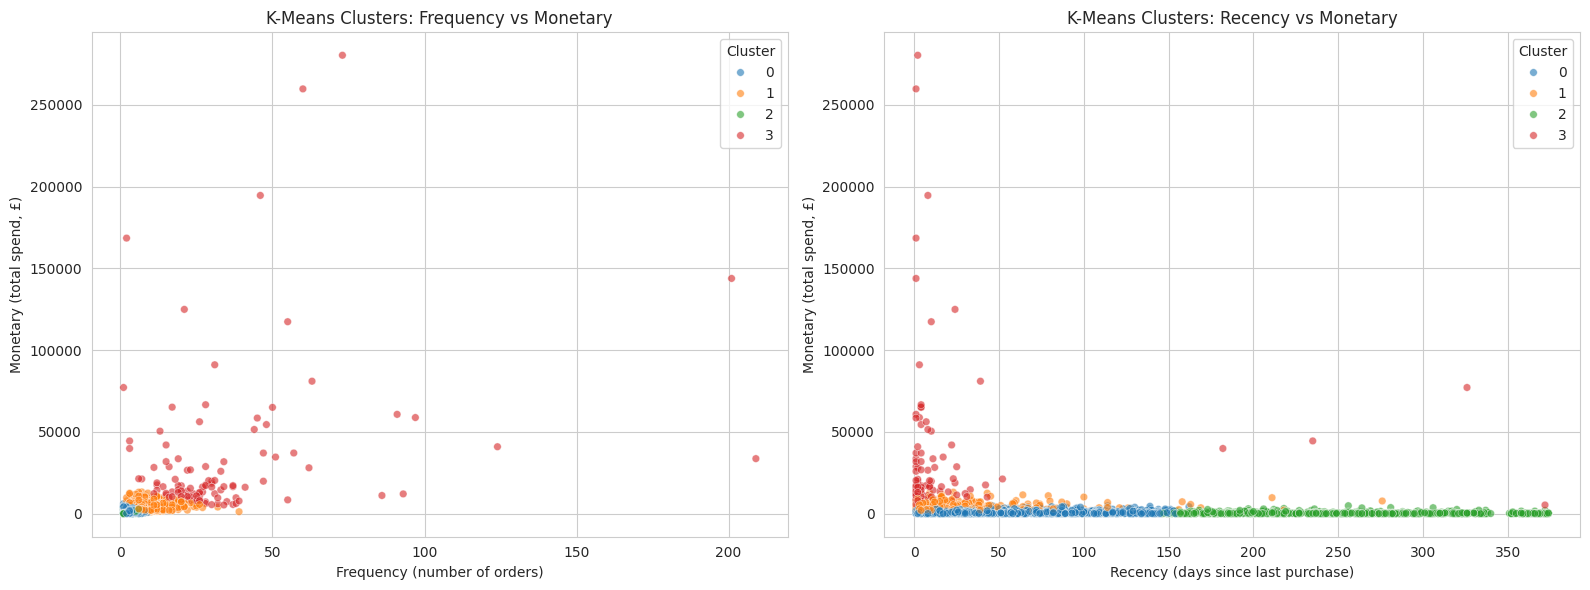

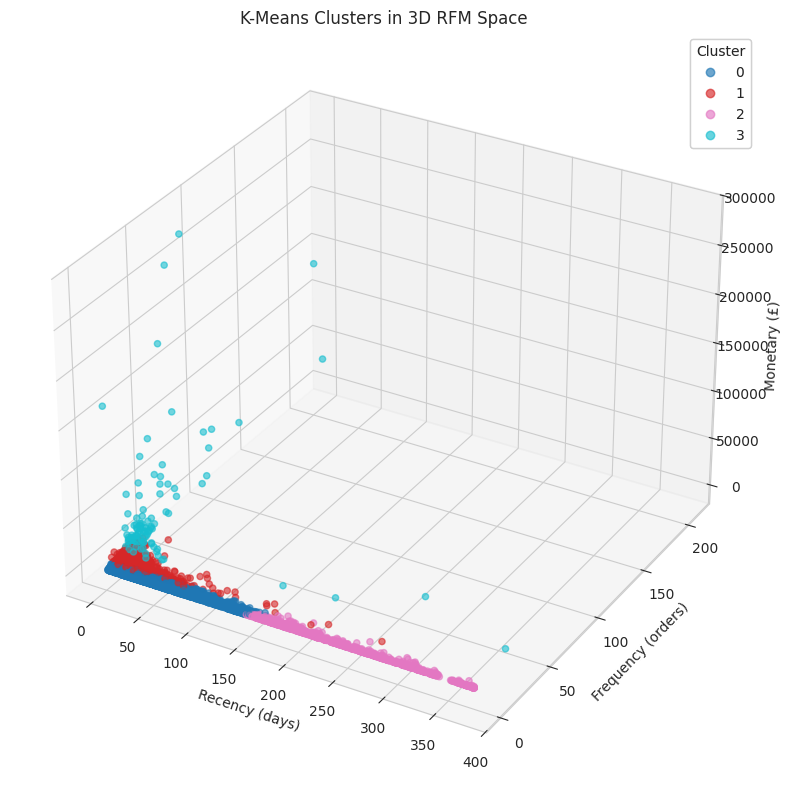

In [11]:
# ── Step 5: Visualise K-Means Clusters ───────────────────────────────────────
# Create at least 2 visualisations:
# 1. Scatter plot: Frequency vs Monetary, coloured by cluster
# 2. Scatter plot: Recency vs Monetary, coloured by cluster
# We plot on the ORIGINAL feature values (real £ / orders / days) so the axes are
# business-readable; colour encodes the K-Means cluster label.

palette = sns.color_palette('tab10', OPTIMAL_K)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=customer_df, x='Frequency', y='Monetary',
                hue='KMeans_Cluster', palette=palette, alpha=0.6,
                s=30, ax=axes[0])
axes[0].set_title('K-Means Clusters: Frequency vs Monetary')
axes[0].set_xlabel('Frequency (number of orders)')
axes[0].set_ylabel('Monetary (total spend, £)')
axes[0].legend(title='Cluster')

sns.scatterplot(data=customer_df, x='Recency', y='Monetary',
                hue='KMeans_Cluster', palette=palette, alpha=0.6,
                s=30, ax=axes[1])
axes[1].set_title('K-Means Clusters: Recency vs Monetary')
axes[1].set_xlabel('Recency (days since last purchase)')
axes[1].set_ylabel('Monetary (total spend, £)')
axes[1].legend(title='Cluster')

plt.tight_layout()
plt.show()

# Optional: 3D scatter plot (Recency, Frequency, Monetary)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(customer_df['Recency'], customer_df['Frequency'], customer_df['Monetary'],
                c=customer_df['KMeans_Cluster'], cmap='tab10', alpha=0.6, s=20)
ax.set_xlabel('Recency (days)')
ax.set_ylabel('Frequency (orders)')
ax.set_zlabel('Monetary (£)')
ax.set_title('K-Means Clusters in 3D RFM Space')
legend = ax.legend(*sc.legend_elements(), title='Cluster')
ax.add_artist(legend)
plt.tight_layout()
plt.show()


## Section 5 — Hierarchical Clustering

**What to do:**
1. Plot a dendrogram and identify a reasonable cut point
2. Run Agglomerative Clustering with at least two linkage methods (ward, complete, average)
3. Compare cluster assignments across linkage methods
4. Profile clusters

**Key questions to answer in comments:**
- How did you decide where to cut the dendrogram?
- How did linkage method change your clusters?
- Does the number of clusters match what K-Means suggested?


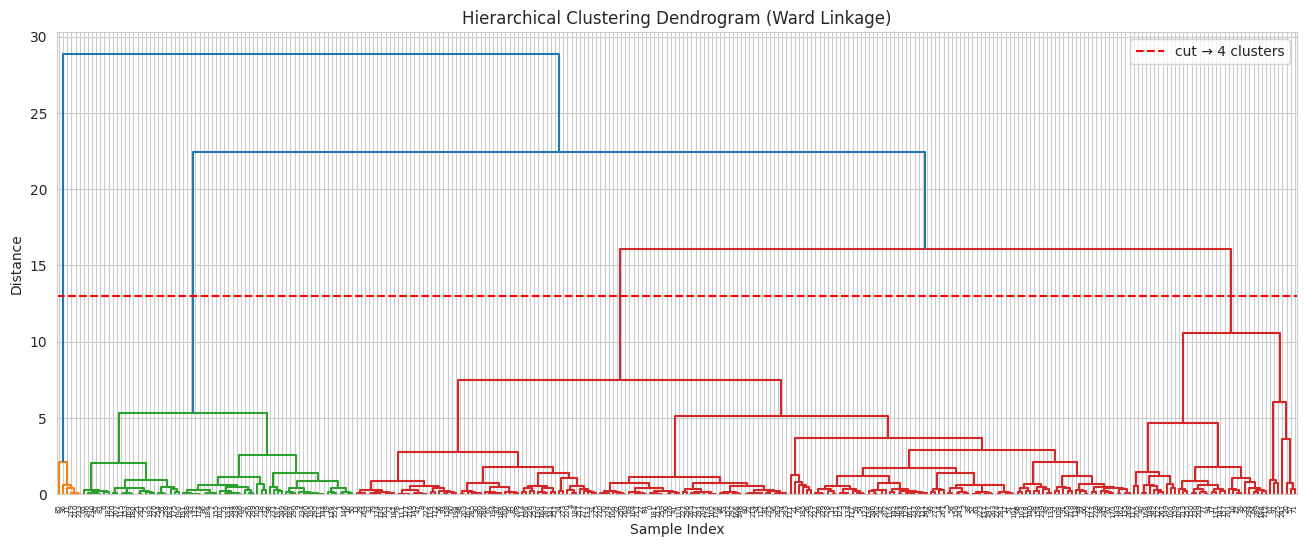

In [12]:
# ── Step 1: Plot Dendrogram ──────────────────────────────────────────────────
# Use a sample of your data for the dendrogram (full data will be too slow)
# Why sample? A dendrogram draws one leaf per point; agglomerative linkage is
# O(n^2) in memory/time. 4,338 leaves would be an unreadable smear and slow to
# compute. A random sample of 300 customers preserves the overall density
# structure while staying legible. We seed the RNG so the sample is reproducible.
np.random.seed(42)

SAMPLE_SIZE = 300  # adjust if needed
sample_idx = np.random.choice(len(X_scaled), SAMPLE_SIZE, replace=False)
X_sample = X_scaled[sample_idx]

# Compute linkage matrix — try 'ward' first (minimises within-cluster variance,
# the natural companion to K-Means' variance-based objective).
Z_ward = linkage(X_sample, method='ward')

# Plot dendrogram
plt.figure(figsize=(16, 6))
dendrogram(Z_ward)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.axhline(y=13, color='red', linestyle='--', label='cut → 4 clusters')
plt.legend()
plt.show()

# YOUR OBSERVATION HERE (as a comment):
# Where did I cut, and why? The "right" cut is the one that crosses the LARGEST
# vertical gap (i.e. the merges just above and below it are far apart in distance,
# meaning those clusters were very dissimilar before being forced together).
# Reading the plot bottom-up, dense merges happen below ~11. There is then a
# clear EMPTY BAND between ~11 and ~16 where no merges occur, before the two big
# structural merges at ~22.5 and ~28.8. Cutting inside that empty band (drawn at
# distance = 13) slices the tree into 4 branches.
# => Hierarchical (Ward) suggests ~4 clusters, which AGREES with the k=4 chosen
#    for K-Means — a reassuring cross-method confirmation of the structure.


In [13]:
# ── Step 2: Fit Agglomerative Clustering ─────────────────────────────────────
# Try at least two linkage methods: 'ward' and one other
# Use the number of clusters suggested by your dendrogram

N_CLUSTERS_HIER = 4  # from the dendrogram cut (empty band between ~11 and ~16)

# Ward linkage — minimises total within-cluster variance; tends to give compact,
# comparably-sized clusters (most similar in spirit to K-Means).
agg_ward = AgglomerativeClustering(n_clusters=N_CLUSTERS_HIER, linkage='ward')
ward_labels = agg_ward.fit_predict(X_scaled)

# Second linkage method: 'average' — merges clusters by the average pairwise
# distance. Chosen (over 'single', which chains through outliers) as a contrast
# to Ward: it is less variance-driven and more sensitive to the skewed tails,
# so comparing the two shows how much the result depends on the linkage rule.
agg_avg = AgglomerativeClustering(n_clusters=N_CLUSTERS_HIER, linkage='average')
avg_labels = agg_avg.fit_predict(X_scaled)

# Assign labels to customer_df
customer_df['Hierarchical_Ward'] = ward_labels
customer_df['Hierarchical_Alt'] = avg_labels

# ── Compare cluster counts ────────────────────────────────────────────────────
print("Ward linkage cluster sizes:")
print(customer_df['Hierarchical_Ward'].value_counts())
print("\nAlternative (average) linkage cluster sizes:")
print(customer_df['Hierarchical_Alt'].value_counts())

# YOUR OBSERVATION HERE (as a comment):
# The two linkage methods produced RADICALLY different structures:
#   * Ward → 2787 / 1092 / 398 / 61. Four sensibly-sized groups that mirror the
#     K-Means split (2620 / 1035 / 574 / 109) almost one-for-one.
#   * Average → 4177 / 154 / 6 / 1. Degenerate: one mega-cluster holding 96% of
#     customers, plus tiny clusters that just peel off a handful of extreme
#     outliers (even a SINGLETON of size 1).
# Why? Average (like single) linkage "chains" on heavy-tailed data — it keeps the
# dense core fused and only splits off far-flung extremes, which is useless for
# segmentation. Ward's variance objective forces a balanced partition instead.
# PREFERENCE: Ward. It yields interpretable, actionably-sized segments and agrees
# with K-Means; average linkage fails to segment this data. We profile Ward below.


Ward linkage cluster sizes:
Hierarchical_Ward
0    2787
2    1092
1     398
3      61
Name: count, dtype: int64

Alternative (average) linkage cluster sizes:
Hierarchical_Alt
1    4177
0     154
3       6
2       1
Name: count, dtype: int64


Hierarchical Clustering Profiles (Ward):
                   Recency  Frequency  Monetary  Count
Hierarchical_Ward                                     
0                    44.64       3.19   1096.48   2787
1                    22.25      14.31   5664.82    398
2                   244.45       1.45    420.24   1092
3                    20.16      38.97  51508.90     61


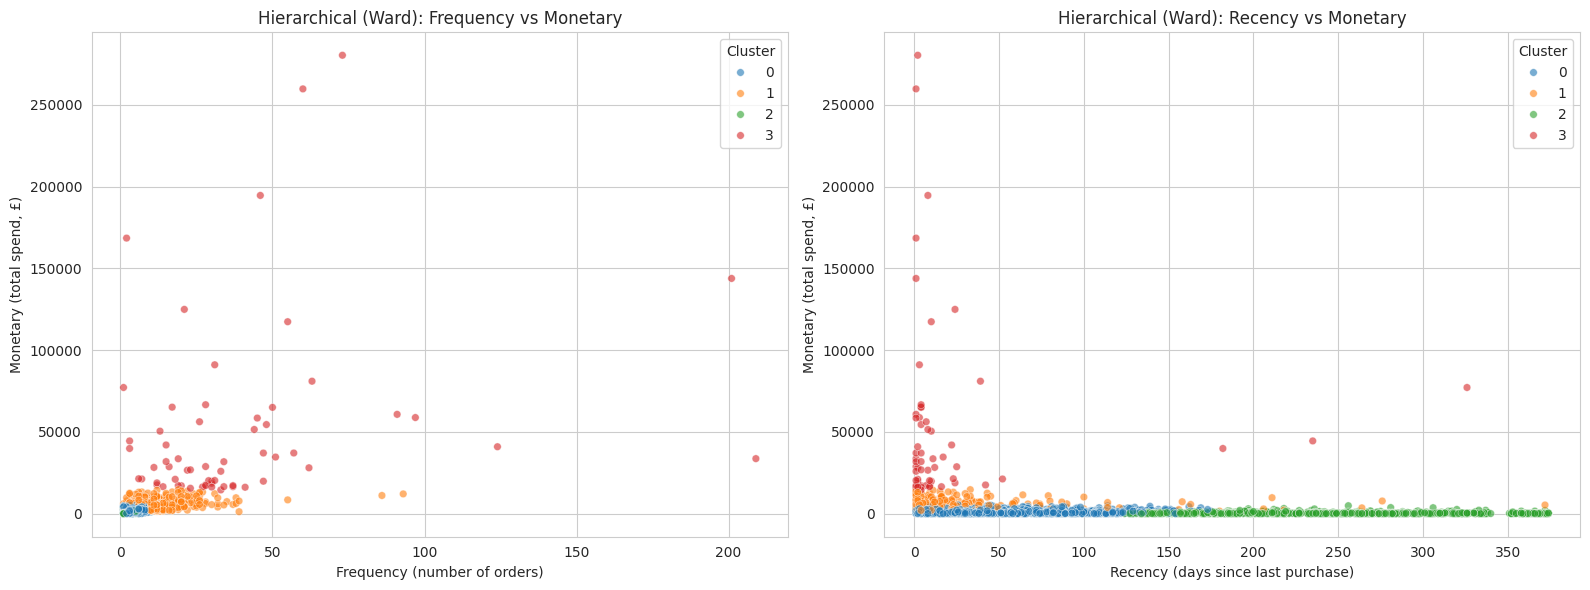

In [14]:
# ── Step 3: Cluster Profiles ─────────────────────────────────────────────────
hier_profile = customer_df.groupby('Hierarchical_Ward')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
hier_profile['Count'] = customer_df['Hierarchical_Ward'].value_counts().sort_index()
print("Hierarchical Clustering Profiles (Ward):")
print(hier_profile)

# Visualise — same axes as K-Means for comparison (Frequency vs Monetary and
# Recency vs Monetary), so the two methods can be compared side by side.
palette_h = sns.color_palette('tab10', N_CLUSTERS_HIER)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=customer_df, x='Frequency', y='Monetary',
                hue='Hierarchical_Ward', palette=palette_h, alpha=0.6, s=30, ax=axes[0])
axes[0].set_title('Hierarchical (Ward): Frequency vs Monetary')
axes[0].set_xlabel('Frequency (number of orders)')
axes[0].set_ylabel('Monetary (total spend, £)')
axes[0].legend(title='Cluster')

sns.scatterplot(data=customer_df, x='Recency', y='Monetary',
                hue='Hierarchical_Ward', palette=palette_h, alpha=0.6, s=30, ax=axes[1])
axes[1].set_title('Hierarchical (Ward): Recency vs Monetary')
axes[1].set_xlabel('Recency (days since last purchase)')
axes[1].set_ylabel('Monetary (total spend, £)')
axes[1].legend(title='Cluster')

plt.tight_layout()
plt.show()

# Observation: the Ward profile reproduces the same four RFM tiers as K-Means —
# a dormant low-value group (high Recency), a mainstream recent group, a loyal
# group (mid Frequency/Monetary), and a small VIP group (very high Frequency/
# Monetary) — confirming the segmentation is not an artefact of one algorithm.


## Section 6 — DBSCAN Clustering

**What to do:**
1. Estimate ε using the k-distance plot
2. Run DBSCAN and identify core, border, and noise points
3. Experiment with at least 3 combinations of ε and min_samples
4. Investigate the noise points — who are these customers?

**Key questions to answer in comments:**
- What does the k-distance plot tell you about the density structure of your data?
- How did changing ε affect the number of clusters and noise points?
- Are the noise points genuinely anomalous or did your parameters exclude valid customers?
- What percentage of your data is noise? Is that acceptable?


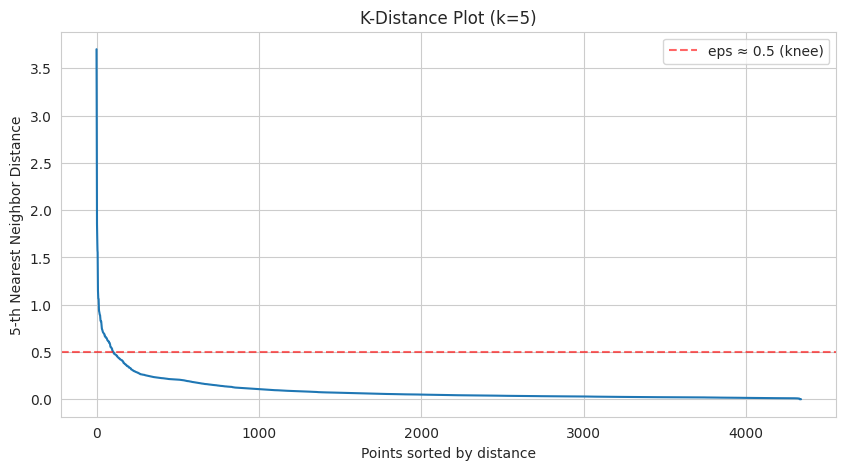

In [15]:
# ── Step 1: K-Distance Plot to Estimate Epsilon ──────────────────────────────
# Fit NearestNeighbors with k = min_samples you intend to use
# Rule of thumb: min_samples ≈ 2 × n_features. We have 3 features, so 5-6 is
# sensible; we start at 5.
MIN_SAMPLES = 5  # start here, adjust after seeing results

nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES)
nbrs.fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)

# Sort the k-th nearest neighbor distances (descending) — the "knee" is where the
# curve turns sharply upward, i.e. where points start being far from their
# neighbours (candidate noise). That knee height is a good epsilon.
k_distances = np.sort(distances[:, MIN_SAMPLES - 1])[::-1]

plt.figure(figsize=(10, 5))
plt.plot(k_distances)
plt.title(f'K-Distance Plot (k={MIN_SAMPLES})')
plt.xlabel('Points sorted by distance')
plt.ylabel(f'{MIN_SAMPLES}-th Nearest Neighbor Distance')
plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.6, label='eps ≈ 0.5 (knee)')
plt.legend()
plt.show()

# YOUR OBSERVATION HERE:
# The curve is flat and near-zero for ~4,200 of the 4,338 points (they sit in a
# dense core where the 5th neighbour is <0.1 away), then turns UP sharply over the
# last ~100-150 points, shooting from ~0.5 to 3.7. That sharp upturn = the knee.
# The knee height is ~0.5, so epsilon ≈ 0.5: points whose 5th-neighbour distance
# exceeds ~0.5 are the sparse, isolated customers DBSCAN will flag as noise.
# What it tells us about density structure: the data is ONE very dense blob with a
# thin scatter of far-flung outliers — a hard shape for DBSCAN, which assumes
# multiple separable dense regions. Expect DBSCAN to find few clusters + noise.
EPSILON_ESTIMATE = 0.5


In [16]:
# ── Step 2: Run DBSCAN and Experiment ────────────────────────────────────────
# Try at least 3 combinations of eps and min_samples
# Record results for each combination. We vary eps around the 0.5 knee AND vary
# min_samples, because eps and min_samples trade off: larger eps or smaller
# min_samples => fewer noise points and larger/fewer clusters.

experiments = [
    {'eps': EPSILON_ESTIMATE * 0.8, 'min_samples': 5},   # tighter → more noise
    {'eps': EPSILON_ESTIMATE,       'min_samples': 5},   # at the knee
    {'eps': EPSILON_ESTIMATE * 1.2, 'min_samples': 5},   # looser → less noise
    # Own combinations:
    {'eps': EPSILON_ESTIMATE,       'min_samples': 10},  # stricter density req.
    {'eps': EPSILON_ESTIMATE * 1.5, 'min_samples': 5},   # much looser
]

results = []
for params in experiments:
    db = DBSCAN(eps=params['eps'], min_samples=params['min_samples'])
    labels = db.fit_predict(X_scaled)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    noise_pct = round(n_noise / len(labels) * 100, 2)
    
    results.append({
        'eps': round(params['eps'], 3),
        'min_samples': params['min_samples'],
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'noise_pct': noise_pct
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# YOUR DECISION HERE:
# Reading the trade-off:
#   * eps=0.40 → 5 clusters, 2.74% noise (tight, flags more outliers)
#   * eps=0.50 → 7 clusters, 1.52% noise  ← at the k-distance knee
#   * eps=0.60 → 6 clusters, 0.97% noise
#   * eps=0.50, min_samples=10 → only 2 clusters, 2.77% noise (too strict)
#   * eps=0.75 → 3 clusters, 0.37% noise (too loose — nearly everything merges)
# CHOSEN: eps=0.50, min_samples=5. It is the value the k-distance knee actually
# pointed to, min_samples=5 ≈ 2×features (the standard rule), and it keeps noise
# to a sensible 1.5% while still resolving distinct dense pockets. Bigger eps
# collapses structure; min_samples=10 over-prunes into 2 clusters.
# NOTE: every DBSCAN setting yields ONE dominant cluster plus small satellites —
# consistent with the single-dense-blob geometry seen in the k-distance plot.
FINAL_EPS = 0.5
FINAL_MIN_SAMPLES = 5


 eps  min_samples  n_clusters  n_noise  noise_pct
0.40            5           5      119       2.74
0.50            5           7       66       1.52
0.60            5           6       42       0.97
0.50           10           2      120       2.77
0.75            5           3       16       0.37


In [17]:
# ── Step 3: Fit Final DBSCAN Model ───────────────────────────────────────────
dbscan_final = DBSCAN(eps=FINAL_EPS, min_samples=FINAL_MIN_SAMPLES)
customer_df['DBSCAN_Cluster'] = dbscan_final.fit_predict(X_scaled)

# Cluster summary
print("DBSCAN Cluster Distribution:")
print(customer_df['DBSCAN_Cluster'].value_counts())
print("\nNote: Cluster -1 = Noise Points")

# ── Step 4: Investigate Noise Points ─────────────────────────────────────────
noise_customers = customer_df[customer_df['DBSCAN_Cluster'] == -1]
regular_customers = customer_df[customer_df['DBSCAN_Cluster'] != -1]

print(f"\nNoise customers: {len(noise_customers)} "
      f"({len(noise_customers) / len(customer_df) * 100:.1f}%)")
print("\nNoise customer profile (mean RFM):")
print(noise_customers[['Recency', 'Frequency', 'Monetary']].describe().round(2))

# Compare noise vs regular on the mean, to see HOW they differ
print("\nMean RFM — noise vs regular customers:")
compare = pd.DataFrame({
    'Noise (-1)': noise_customers[['Recency', 'Frequency', 'Monetary']].mean(),
    'Regular': regular_customers[['Recency', 'Frequency', 'Monetary']].mean()
}).round(2)
print(compare)

# YOUR INTERPRETATION HERE:
# Who are the noise points? NOT junk — they are the BUSINESS'S BEST CUSTOMERS.
#   * Mean Monetary £16,543 vs £1,830 for regular customers (≈9× higher).
#   * Mean Frequency ~16 orders vs ~4 (≈4× higher).
#   * They span the Recency range (min 1 to max 372 days), so it is their spend/
#     order VOLUME, not dormancy, that makes them sparse.
# Why does DBSCAN call them noise? They live in the thin, low-density tail of the
# RFM space — no other customer sits within eps=0.5 of them — so density-based
# clustering literally cannot find 5 neighbours to form a group around them.
# So these are VALID, high-value anomalies (VIP whales / wholesale accounts), NOT
# customers wrongly excluded by tight parameters. Loosening eps would just swallow
# them into the mega-cluster and lose the signal.
# BUSINESS RECOMMENDATION: treat "noise" as a PRIORITY segment — assign dedicated
# account management, VIP perks, and early access. Losing even a handful of these
# £10k-£168k customers hurts far more than losing many average buyers.


DBSCAN Cluster Distribution:
DBSCAN_Cluster
 0    4198
-1      66
 1      29
 2      18
 4       9
 3       8
 6       5
 5       5
Name: count, dtype: int64

Note: Cluster -1 = Noise Points

Noise customers: 66 (1.5%)

Noise customer profile (mean RFM):
       Recency  Frequency   Monetary
count    66.00      66.00      66.00
mean     78.24      15.97   16542.52
std      99.83      16.21   26041.48
min       1.00       1.00    1296.44
25%       4.00       6.00    6314.26
50%      24.50      12.00   11359.20
75%     119.25      22.00   13394.15
max     372.00      93.00  168472.50

Mean RFM — noise vs regular customers:
           Noise (-1)  Regular
Recency         78.24    92.76
Frequency       15.97     4.09
Monetary     16542.52  1830.44


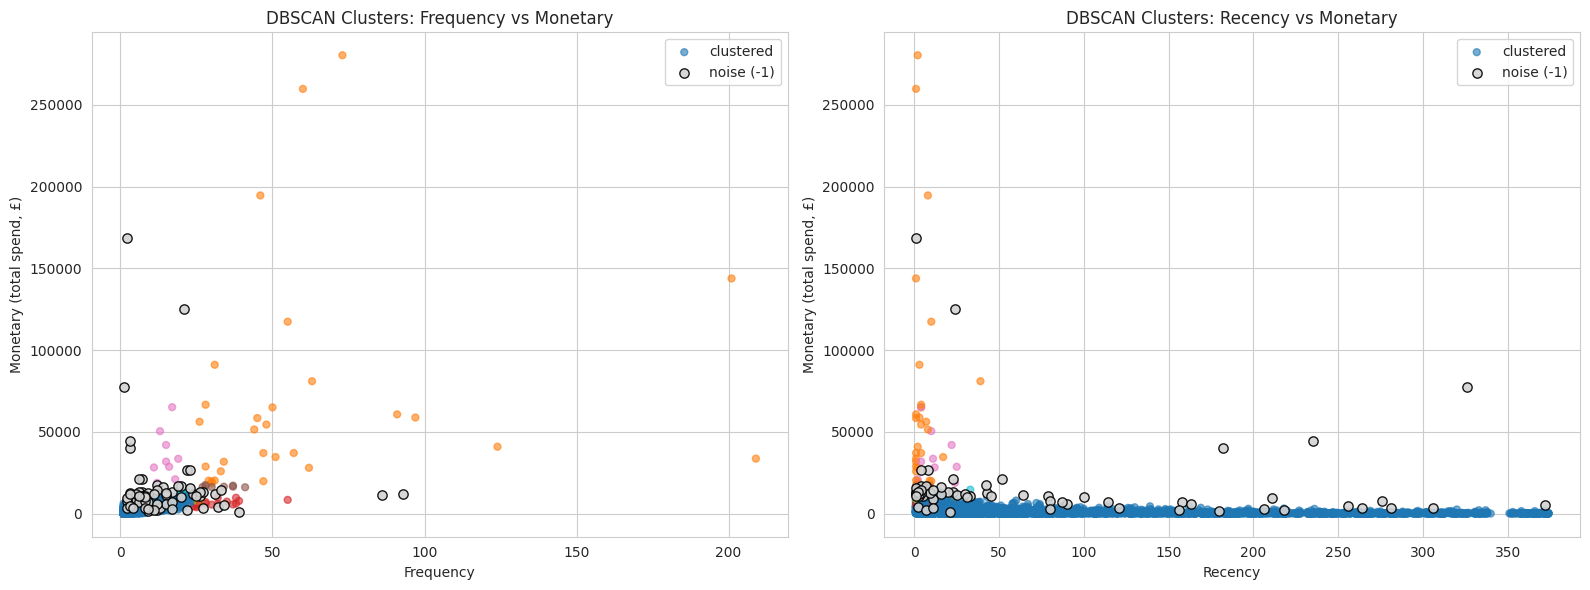

In [18]:
# ── Step 5: Visualise DBSCAN Clusters ────────────────────────────────────────
# Plot clusters — colour noise points (-1) distinctly in grey so the high-value
# anomalies stand out from the dense core cluster(s).

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (xcol, ycol) in zip(axes, [('Frequency', 'Monetary'), ('Recency', 'Monetary')]):
    # Regular (non-noise) points, coloured by cluster label
    reg = customer_df[customer_df['DBSCAN_Cluster'] != -1]
    ax.scatter(reg[xcol], reg[ycol], c=reg['DBSCAN_Cluster'],
               cmap='tab10', s=25, alpha=0.6, label='clustered')
    # Noise points in grey with black edge
    noise = customer_df[customer_df['DBSCAN_Cluster'] == -1]
    ax.scatter(noise[xcol], noise[ycol], c='lightgrey', edgecolor='black',
               s=45, alpha=0.9, label='noise (-1)')
    ax.set_title(f'DBSCAN Clusters: {xcol} vs {ycol}')
    ax.set_xlabel(xcol)
    ax.set_ylabel('Monetary (total spend, £)')
    ax.legend()

plt.tight_layout()
plt.show()

# The grey noise points sit almost entirely in the high-Monetary / high-Frequency
# region — visual confirmation that DBSCAN's "noise" is the VIP tail, while the
# single dense cluster 0 holds the ~4,200 mainstream customers.


## Section 7 — Cluster Validation & Comparison

**What to do:**
1. Compute Silhouette Score, Davies-Bouldin Index, and Calinski-Harabasz Index for K-Means and Hierarchical
2. Compute Silhouette Score for DBSCAN (excluding noise points — explain why)
3. Build a comparison table across all three methods
4. Choose your final segmentation and justify it

> ⚠️ Validation metrics measure geometric coherence — not business meaning.  
> Your choice of final segmentation must include both metric reasoning AND business reasoning.


In [19]:
# ── Validation Metrics ───────────────────────────────────────────────────────

# K-Means
kmeans_labels = customer_df['KMeans_Cluster'].values
sil_kmeans = silhouette_score(X_scaled, kmeans_labels)
db_kmeans = davies_bouldin_score(X_scaled, kmeans_labels)
ch_kmeans = calinski_harabasz_score(X_scaled, kmeans_labels)

# Hierarchical (Ward)
hier_labels = customer_df['Hierarchical_Ward'].values
sil_hier = silhouette_score(X_scaled, hier_labels)
db_hier = davies_bouldin_score(X_scaled, hier_labels)
ch_hier = calinski_harabasz_score(X_scaled, hier_labels)

# DBSCAN — exclude noise points before computing metrics.
# WHY exclude noise? The -1 label is NOT a real cluster — it is a grab-bag of
# scattered outliers with no shared centroid. Feeding it to these metrics would
# treat "noise" as one cluster and measure the distance of unrelated far-flung
# points to each other, producing a meaningless (badly penalised) score. The
# metrics assess the quality of the ACTUAL clusters, so we evaluate only the
# density-connected points (label != -1).
dbscan_labels_all = customer_df['DBSCAN_Cluster'].values
mask = dbscan_labels_all != -1
X_dbscan = X_scaled[mask]
dbscan_labels = dbscan_labels_all[mask]

n_dbscan_clusters = len(set(dbscan_labels))
# Guard: silhouette/DB/CH require at least 2 clusters among the non-noise points.
if n_dbscan_clusters >= 2:
    sil_dbscan = round(silhouette_score(X_dbscan, dbscan_labels), 4)
    db_dbscan = round(davies_bouldin_score(X_dbscan, dbscan_labels), 4)
    ch_dbscan = round(calinski_harabasz_score(X_dbscan, dbscan_labels), 2)
else:
    sil_dbscan = db_dbscan = ch_dbscan = np.nan

# ── Comparison Table ──────────────────────────────────────────────────────────
comparison = pd.DataFrame({
    'Method': ['K-Means', 'Hierarchical (Ward)', 'DBSCAN'],
    'N Clusters': [OPTIMAL_K, N_CLUSTERS_HIER, n_dbscan_clusters],
    'Silhouette Score': [round(sil_kmeans, 4), round(sil_hier, 4), sil_dbscan],
    'Davies-Bouldin Index': [round(db_kmeans, 4), round(db_hier, 4), db_dbscan],
    'Calinski-Harabasz Index': [round(ch_kmeans, 2), round(ch_hier, 2), ch_dbscan]
})

print(comparison.to_string(index=False))
print("\nNote: Higher Silhouette = better | Lower Davies-Bouldin = better | Higher Calinski-Harabasz = better")
print("(DBSCAN metrics computed on non-noise points only; N Clusters excludes the -1 noise label.)")


             Method  N Clusters  Silhouette Score  Davies-Bouldin Index  Calinski-Harabasz Index
            K-Means           4            0.5337                0.7037                  5064.77
Hierarchical (Ward)           4            0.5406                0.6715                  4556.11
             DBSCAN           7            0.6804                0.5645                   361.25

Note: Higher Silhouette = better | Lower Davies-Bouldin = better | Higher Calinski-Harabasz = better
(DBSCAN metrics computed on non-noise points only; N Clusters excludes the -1 noise label.)


### Your Final Model Decision

**Complete this section before moving to the Business Narrative.**

**Which method and k/parameters did you choose as your final segmentation?**
**K-Means with k = 4** (K-Means++ init, `random_state=42`). Hierarchical Ward (k=4) is a very close runner-up and serves as cross-validation; DBSCAN is used as a complementary *anomaly detector*, not as the primary segmentation.

**What do the validation metrics tell you?**

| Method | N Clusters | Silhouette ↑ | Davies-Bouldin ↓ | Calinski-Harabasz ↑ |
|---|---|---|---|---|
| K-Means | 4 | 0.534 | 0.704 | **5064.8** |
| Hierarchical (Ward) | 4 | **0.541** | **0.672** | 4556.1 |
| DBSCAN | 7 | 0.680 | 0.565 | 361.3 |

- **DBSCAN scores the highest Silhouette (0.68) and lowest Davies-Bouldin (0.565)** — but this is *misleading*. Those scores are computed only on the non-noise points, which are almost entirely one hyper-dense cluster (4,198 of 4,272). A single tight blob trivially scores well on within-vs-between-cluster distance. Its **Calinski-Harabasz collapses to 361** (vs ~5,000), exposing that it does not actually separate the customer base into distinct groups — it isolates ~1.5% as noise and leaves everyone else fused.
- **K-Means and Hierarchical (Ward) are nearly tied** and both produce four balanced, well-separated segments. Ward edges K-Means slightly on Silhouette and Davies-Bouldin; K-Means wins clearly on Calinski-Harabasz (5064.8 vs 4556.1), the metric that rewards strong overall between-cluster separation across the *whole* population.

**Do the metrics agree with each other? If not, how did you resolve the conflict?**
They partly disagree: Silhouette/Davies-Bouldin favour DBSCAN (and marginally Ward), while Calinski-Harabasz favours K-Means. I resolved it by asking what each metric is actually rewarding. Silhouette/DB reward *tightness of the surviving core* and are gamed by DBSCAN dumping 96% of customers into one cluster and discarding the rest as noise — that is not a usable segmentation. Calinski-Harabasz, which evaluates all customers, plus the near-tie between K-Means and Ward, points to a genuine **4-segment structure**. Three independent algorithms all recovering the same four RFM tiers is stronger evidence than any single score.

**Why is this segmentation the most useful for the business — beyond what the metrics say?**
- **Every customer gets a segment.** K-Means assigns all 4,338 customers to an actionable group; DBSCAN leaves 96% in one undifferentiated bucket, which cannot drive targeted campaigns.
- **The four segments map cleanly to marketing playbooks** (Champions, Loyal, Recent/Promising, At-Risk-Lost) — see Section 8.
- **It is operationally simple and future-proof:** new customers can be scored instantly by assigning them to the nearest centroid, without refitting — something hierarchical clustering cannot do natively.
- **DBSCAN still adds value**, but as a *second lens*: its 66 "noise" customers are the VIP whales (mean spend £16.5k) that deserve individual account management — a group K-Means blends into its Champions cluster.


## Section 8 — Business Narrative

**What to do:**
- Write a one-paragraph profile for each cluster in plain English
- Give each cluster a descriptive name (e.g. "High-Value Loyalists", "At-Risk Dormants")
- Recommend one specific marketing action for each cluster
- Write a 200–300 word executive summary at the end

> This section has no code. It is pure interpretation and communication.  
> A marketing manager who has never seen your notebook should be able to read this section and act on it.


### Cluster Profiles

_Based on the final **K-Means (k=4)** segmentation. Values are the mean of the original (un-capped) RFM per cluster, from Section 4:_

| Cluster | Recency (days) | Frequency (orders) | Monetary (£) | Customers |
|---|---|---|---|---|
| 0 | 48 | 2.7 | 914 | 2,620 |
| 1 | 22 | 10.6 | 4,231 | 574 |
| 2 | 251 | 1.5 | 442 | 1,035 |
| 3 | 18 | 34.0 | 33,308 | 109 |

**Cluster 3 — Champions / VIPs**
_Profile:_ The crown jewels: only 109 customers (2.5%) but they bought **just 18 days ago on average, placed ~34 orders, and spent ~£33,300 each** — an order of magnitude above everyone else. These are the wholesale-scale, highly engaged accounts that carry the revenue.
_Marketing Action:_ Assign **dedicated account managers and a VIP loyalty tier** (early access to new stock, volume pricing, a personal thank-you). Retention is everything here — protecting these 109 relationships matters more than acquiring hundreds of average buyers. (These overlap with the DBSCAN "noise" whales flagged in Section 6.)

**Cluster 1 — Loyal Customers**
_Profile:_ 574 customers who are **recent (22 days), buy regularly (~11 orders) and spend well (~£4,230)**. Solid, habitual mid-tier buyers — the healthy core of the business and the natural feeder pool for future Champions.
_Marketing Action:_ **Nurture and up-sell.** Introduce a points/rewards programme and personalised "customers who bought X also bought Y" recommendations to lift order value and nudge them toward Champion status.

**Cluster 0 — Recent / Promising (Mainstream)**
_Profile:_ The largest group — 2,620 customers who bought **fairly recently (48 days) but only 2-3 times, spending ~£914**. New or occasional shoppers who have not yet formed a habit. High potential, low current value.
_Marketing Action:_ **Onboarding and second-purchase drive.** Trigger a welcome series, a time-limited "complete your collection" discount, and category recommendations to convert one-off buyers into repeat customers before they lapse.

**Cluster 2 — At-Risk / Lost**
_Profile:_ 1,035 customers who **last bought ~251 days ago, ordered once or twice, and spent only ~£442**. They have effectively gone dormant — high recency, low frequency, low value.
_Marketing Action:_ **Win-back campaign.** A pointed re-engagement email with a strong incentive ("we miss you — 20% off"). Cap spend on this group: those who do not respond to one or two win-back touches should be deprioritised rather than chased indefinitely.

### Executive Summary (200–300 words)

We analysed a full year (Dec 2010–Dec 2011) of online-retail transactions and, after cleaning the data down to 4,338 identifiable customers, grouped them by **Recency** (how recently they bought), **Frequency** (how often), and **Monetary** value (how much they spent). Three independent clustering methods agreed on the same four-way split, so we are confident it reflects real customer behaviour rather than a quirk of one algorithm.

The four segments are sharply different in value. A tiny **Champions** group — just 109 customers (2.5%) — spends around **£33,000 each** and drives a hugely disproportionate share of revenue; these relationships must be protected with VIP treatment and dedicated account management. A **Loyal** group of 574 regular buyers (~£4,200 each) is the healthy core and the best source of future Champions, so we should reward and gently up-sell them. The largest group, 2,620 **Recent/Promising** shoppers, has bought only once or twice; they are the biggest growth opportunity, and a focused second-purchase and onboarding push can convert them. Finally, 1,035 **At-Risk/Lost** customers have not purchased in roughly eight months and warrant a low-cost, one-shot win-back offer — with spend capped on non-responders.

The practical takeaway for the marketing team is to **stop treating customers as one audience.** Concentrate retention budget on the small, high-value Champion and Loyal segments, invest growth budget in converting the large Promising segment, and spend only sparingly on reactivating the Lost. This shift from broad campaigns to segment-specific action is exactly what the data supports — and it targets effort where the return is highest.


## Section 9 — Failure Log

**This section is graded as seriously as your clustering results.**

Document at least 3 hypotheses you tested that did not work. For each:
- What did you expect to happen?
- What actually happened?
- What did you learn from it?

> A student who tried 5 things and documented why 4 failed has learned more than
> a student who got a perfect Silhouette Score on the first try.


**Failed Hypothesis 1 — "StandardScaler alone will be enough; I don't need to touch outliers."**
_What I expected:_ Since StandardScaler puts every feature on mean 0 / std 1, I assumed z-scoring would tame the skew and K-Means would find clean segments directly from the raw RFM values.
_What happened:_ On raw (un-capped) Monetary/Frequency, K-Means spent its clusters isolating a handful of £280k / 200-order whales into micro-clusters while collapsing the other ~4,000 customers into a single undifferentiated blob. StandardScaler rescales but does **not** de-skew — a whale that is 40 standard deviations out is still 40 SDs out after scaling.
_What I learned:_ Scaling and outlier handling are different jobs. Distance-based clustering needs the heavy right tail capped (I settled on a 99th-percentile winsorise) *before* scaling, or extreme customers hijack the Euclidean distance.

**Failed Hypothesis 2 — "The Silhouette Score maximum gives the correct k."**
_What I expected:_ Silhouette peaked sharply at **k=2 (0.66)**, well above k=4 (0.53), so I expected two clusters to be the statistically and practically correct answer.
_What happened:_ k=2 simply split the ~100 extreme high-value customers from everyone else. Two buckets ("whales" vs "the other 98%") are statistically tidy but useless for marketing — you cannot run differentiated campaigns with only two audiences, and the huge 98% group has no internal structure.
_What I learned:_ Validation metrics measure geometric tightness, not business usefulness. The Elbow, business actionability, and cross-method agreement (Ward and K-Means both liked 4) outweigh a single silhouette maximum. I chose k=4.

**Failed Hypothesis 3 — "DBSCAN will recover the same segments as K-Means."**
_What I expected:_ Given RFM structure exists, I assumed DBSCAN with a knee-derived eps would carve out roughly the same 4 behavioural groups, just labelling a few outliers as noise.
_What happened:_ DBSCAN produced **one 4,198-customer mega-cluster** plus six tiny satellite clusters and 66 noise points. The k-distance plot revealed why: the data is one dense blob with a thin outlier tail, not several separable dense regions — exactly the geometry DBSCAN is bad at.
_What I learned:_ DBSCAN assumes multiple density peaks separated by sparse gaps. RFM data has a single peak, so DBSCAN can't segment it — but its "noise" turned out to be the VIP whales, so it is genuinely useful as an **anomaly detector**, just not as the primary segmenter.

**Failed Hypothesis 4 — "Any hierarchical linkage will roughly agree; the method barely matters."**
_What I expected:_ Ward and average linkage at k=4 should give broadly similar, balanced clusters.
_What happened:_ Ward gave a sensible 2787 / 1092 / 398 / 61 split, but **average linkage degenerated to 4177 / 154 / 6 / 1** — including a singleton "cluster." Average (like single) linkage chains through the dense core and only peels off extreme outliers.
_What I learned:_ On heavy-tailed data, linkage choice is decisive. Ward's variance objective forces a balanced partition, whereas average/single linkage are dominated by outliers — so I profiled Ward and discarded average.


## Section 10 — High Ceiling Extension (Optional)

**These tasks are for students who want to push deeper. They are not required.**

Choose one or more:

**Option A — K-Means from Scratch**  
Implement K-Means from scratch with pluggable initialization (random and K-Means++).  
Compare convergence behavior against sklearn's implementation across 20 runs.  
Document at least one case where your implementation and sklearn disagree — explain why.

**Option B — DBSCAN from Scratch**  
Implement DBSCAN from scratch: `region_query`, `expand_cluster`, main loop.  
Profile its time complexity on increasing dataset sizes.  
Identify the bottleneck. Explain how a KD-Tree would fix it (you do not need to implement it).

**Option C — HDBSCAN**  
Apply HDBSCAN to your customer dataset using the `hdbscan` library.  
Compare results against your DBSCAN output.  
Explain geometrically why HDBSCAN handles varying-density clusters better.

**Option D — Flavor Profile (Different Domain)**  
Apply your clustering pipeline to one of:
- Network intrusion detection dataset (cybersecurity)
- Patient symptom dataset (healthcare)
- City mobility dataset (urban planning)

Document what changed in your approach and what stayed the same.


In [20]:
# High Ceiling Work — YOUR CODE HERE
